**环境激活** 
source /home/liyang/miniconda3/etc/profile.d/conda.sh

conda activate  /home/liyang/BioWuYan/conda_env/R43_env

In [1]:
library(Seurat)
# library(clustree)
library(cowplot)
library(data.table)
library(ggplot2)
library(patchwork)
library(stringr)
# library(qs)
library(Matrix)

data_path <- "/home/liyang/BioWuYan/MethodTest/Data/All2/0process/"

atac_dir <- paste0(data_path,  "R/atac/")

rna_dir <- paste0(data_path,  "R/rna/")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




# Data Read
Here, we need load the preprocess data, which processed with the **Preprocess*.ipynb**, but save as **h5ad** file.

配置 **mtx** 的属性，并构建 **meta** 信息，确保 meta 的行与 mtx 的行对应

## ATAC Data

In [3]:
mtx <- readMM(paste0(atac_dir, "sparse.mtx"))

cellinfo <- fread(paste0(atac_dir, "cellinfo.csv"), header = T, data.table = F)

atacinfo <- fread(paste0(atac_dir, "atacinfo.csv"), header = T, data.table = F)

rownames(mtx) <- cellinfo$V1
colnames(mtx) <- atacinfo$V1

meta <- cellinfo
rownames(meta) <- cellinfo$V1

if(identical(rownames(meta), rownames(mtx))){
        # 行需为 feature
    print("Info identical, Can create Seurat Object")
    mtx_transposed <- t(mtx) 

    atac_seurat <- CreateSeuratObject(count = mtx_transposed, meta.data = meta, assay = "ATAC")
}


[1] "Info identical, Can create Seurat Object"


Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


查看数据示例

In [4]:
head(cellinfo)
head(atacinfo)
dim(mtx)

,V1,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_counts,n_genes,leiden
,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<int>,<int>
1,cell_1,65050,11.08293,1221472,14.01557,1221472,65050,2
2,cell_10,64922,11.08096,1221991,14.01599,1221991,64922,0
3,cell_100,65027,11.08257,1224570,14.01810,1224570,65027,4
4,cell_101,65056,11.08302,1225443,14.01881,1225443,65056,5
5,cell_102,65013,11.08236,1225541,14.01889,1225541,65013,1
6,cell_103,65020,11.08247,1225409,14.01879,1225409,65020,2


,V1,chr,start,end,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells,highly_variable,highly_variable_rank,means,variances,variances_norm
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1-10231-10656,chr1,10231,10656,273,1.418,0.8829408,45.4,709,6.565265,273,TRUE,2688,0.006098280,4.927818e-05,5.18393825
2,chr1-629315-630015,chr1,629315,630015,500,1156.558,7.0540679,0.0,578279,13.267813,500,TRUE,1200,0.002027057,1.036276e-09,6.65516771
3,chr1-630813-631351,chr1,630813,631351,500,719.118,6.5794151,0.0,359559,12.792636,500,TRUE,61213,0.002677136,3.957945e-09,0.20586631
4,chr1-631918-632659,chr1,631918,632659,500,831.846,6.7248488,0.0,415923,12.938258,500,TRUE,55933,0.002465824,2.367799e-09,0.42628412
5,chr1-633902-634203,chr1,633902,634203,500,591.102,6.3836789,0.0,295551,12.596600,500,TRUE,67287,0.002977223,6.832030e-09,0.08774578
6,chr1-778414-779184,chr1,778414,779184,500,41.370,3.7464406,0.0,20685,9.937212,500,TRUE,64177,0.006918730,1.573790e-06,0.13541219


[1]   500 72569

## RNA data

In [7]:
rna_mtx <- readMM(paste0(rna_dir, "sparse.mtx"))

rna_cellinfo <- fread(paste0(rna_dir, "cellinfo.csv"), header = T, data.table = F)

rna_info <- fread(paste0(rna_dir, "rnainfo.csv"), header = T, data.table = F)

rownames(rna_mtx) <- cellinfo$V1
colnames(rna_mtx) <- rna_info$V1

meta <- rna_cellinfo
rownames(meta) <- rna_cellinfo$V1


    
print("Create Seurat Object")
rna_mtx_transposed <- t(rna_mtx)
rna_seurat <- CreateSeuratObject(count = rna_mtx_transposed, meta.data = meta, assay = "RNA")


[1] "Create Seurat Object"


Warning message:
“Data is of class dgTMatrix. Coercing to dgCMatrix.”


# Trajectory inference

In [8]:
library(tidyverse)
library(slingshot)
library(Seurat)
library(S4Vectors)
library(SingleCellExperiment)
library(RColorBrewer)
library(arrow)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ tidyr::expand()      masks Matrix::expand()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ tidyr::pack()        masks Matrix::pack()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ lubridate::stamp()   

## 数据处理

In [9]:
# 数据预处理
rna_seurat <- NormalizeData(rna_seurat)
rna_seurat <- FindVariableFeatures(rna_seurat)
rna_seurat <- ScaleData(rna_seurat)
rna_seurat <- RunPCA(rna_seurat)


Normalizing layer: counts



Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Feature1187, Feature1136, Feature853, Feature787, Feature1270, Feature1749, Feature1423, Feature1457, Feature1276, Feature388 
	   Feature1622, Feature1183, Feature1919, Feature494, Feature1033, Feature310, Feature365, Feature1674, Feature1155, Feature1488 
	   Feature1043, Feature526, Feature630, Feature1725, Feature1116, Feature385, Feature483, Feature1715, Feature1807, Feature1657 
Negative:  Feature994, Feature59, Feature1315, Feature1583, Feature660, Feature857, Feature1330, Feature1404, Feature636, Feature1958 
	   Feature1379, Feature69, Feature256, Feature1373, Feature442, Feature1800, Feature191, Feature988, Feature818, Feature640 
	   Feature1142, Feature298, Feature1397, Feature1213, Feature1714, Feature430, Feature267, Feature1007, Feature889, Feature1618 
PC_ 2 
Positive:  Feature1569, Feature1417, Feature1111, Feature29, Feature1826, Feature1682, Feature387, Feature555, Featur

In [10]:
# 提取 PCA 坐标（细胞 x PC）
pca_coords <- rna_seurat@reductions$pca@cell.embeddings[, 1:30]

# 找出重复的行（坐标）的索引
duplicate_cells <- duplicated(pca_coords)

# 统计有多少重复的细胞
num_duplicates <- sum(duplicate_cells)
cat(paste("找到", num_duplicates, "个重复的细胞 (在PCA空间中).\n"))

# 获取重复细胞的名称
duplicate_cell_names <- rownames(pca_coords)[duplicate_cells]

# 过滤掉重复的细胞名称
valid_cells <- setdiff(colnames(rna_seurat), duplicate_cell_names)

original_seurat <- rna_seurat

# 创建一个没有重复细胞的 Seurat 子集对象
rna_seurat <- subset(rna_seurat, cells = valid_cells)

找到 1 个重复的细胞 (在PCA空间中).


In [11]:
# 细胞聚类
rna_seurat <- FindNeighbors(rna_seurat, dims = 1:30)
rna_seurat <- FindClusters(rna_seurat, resolution = 0.5)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 499
Number of edges: 26167

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5000
Number of communities: 1
Elapsed time: 0 seconds


## UMAP & TSNE

In [12]:
# 非线性降维（UMAP/t-SNE）
rna_seurat <- RunUMAP(rna_seurat, dims = 1:30)
rna_seurat <- RunTSNE(rna_seurat, dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
23:13:18 UMAP embedding parameters a = 0.9922 b = 1.112



23:13:18 Read 499 rows and found 30 numeric columns

23:13:18 Using Annoy for neighbor search, n_neighbors = 30

23:13:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

23:13:18 Writing NN index file to temp file /tmp/RtmpQgabHV/file15b6a204398b3

23:13:18 Searching Annoy index using 1 thread, search_k = 3000

23:13:18 Annoy recall = 100%

23:13:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

23:13:20 Initializing from normalized Laplacian + noise (using RSpectra)

23:13:20 Commencing optimization for 500 epochs, with 15430 positive edges

23:13:20 Using rng type: pcg

23:13:22 Optimization finished



## 轨迹推断

In [13]:
# 方法A：直接使用聚类结果
sce <- as.SingleCellExperiment(rna_seurat)

# 运行slingshot - 使用UMAP坐标
sce <- slingshot(sce, 
                clusterLabels = "seurat_clusters", 
                reducedDim = "UMAP",
                start.clus = "0")  # 根据生物学知识指定起始簇

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


In [14]:
# 提取轨迹信息
trajectories <- slingshot::SlingshotDataSet(sce)

# 查看轨迹信息
summary(trajectories)

# 获取伪时间值
pseudotime <- slingshot::slingPseudotime(sce)
curves <- slingshot::slingCurves(sce)

# 查看伪时间矩阵
head(pseudotime)

          Length            Class             Mode 
               1 SlingshotDataSet               S4 

,Lineage1
cell_100,0.5608507
cell_101,5.2880846
cell_102,2.9372417
cell_103,1.7933648
cell_104,3.1443950
cell_105,0.0000000


## 可视化结果

Loading required package: viridisLite



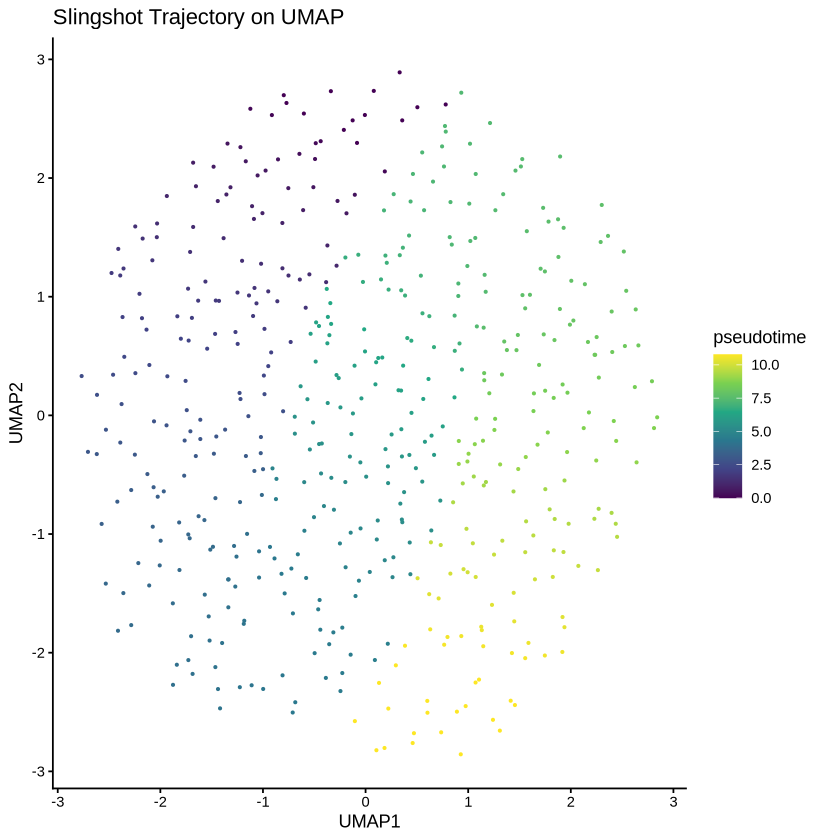

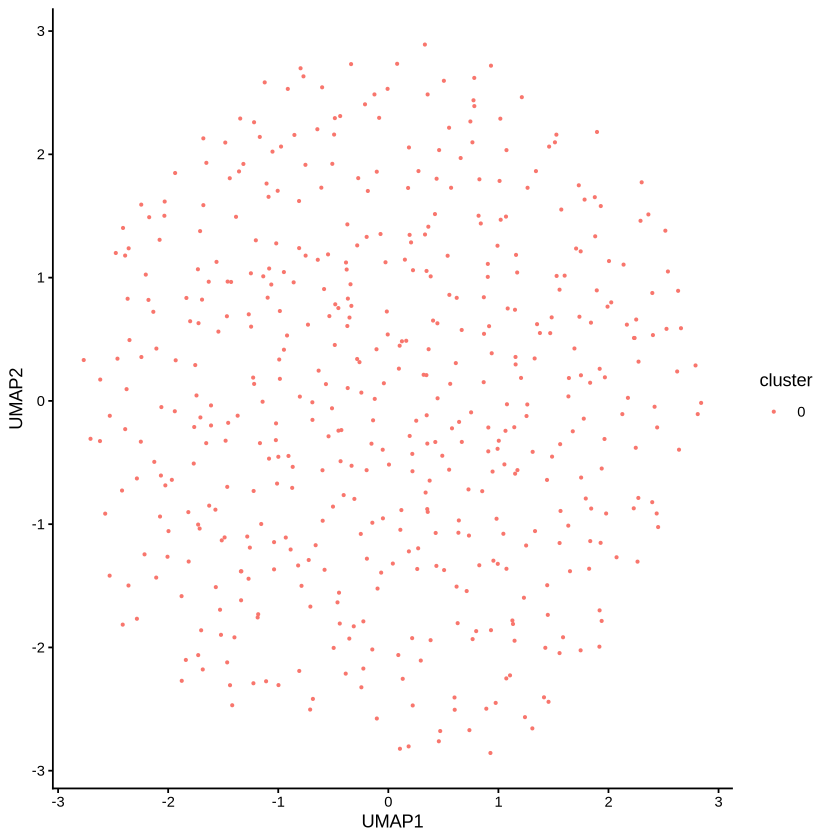

In [15]:
# 可视化
library(ggplot2)
library(viridis)

# 使用UMAP坐标绘制轨迹
umap_df <- as.data.frame(reducedDim(sce, "UMAP"))
colnames(umap_df) <- c("UMAP1", "UMAP2")
umap_df$cluster <- colData(sce)$seurat_clusters
umap_df$pseudotime <- rowSums(pseudotime, na.rm = TRUE)  # 总伪时间

# 绘制轨迹图
ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = pseudotime)) +
  geom_point(size = 0.5) +
  scale_color_viridis_c() +
  theme_classic() +
  labs(title = "Slingshot Trajectory on UMAP")

# 按簇着色查看轨迹
ggplot(umap_df, aes(x = UMAP1, y = UMAP2, color = cluster)) +
  geom_point(size = 0.5) +
  theme_classic()

## 轨迹提取

[1] "Number of cells in each lineage:"
Lineage1 
     499 


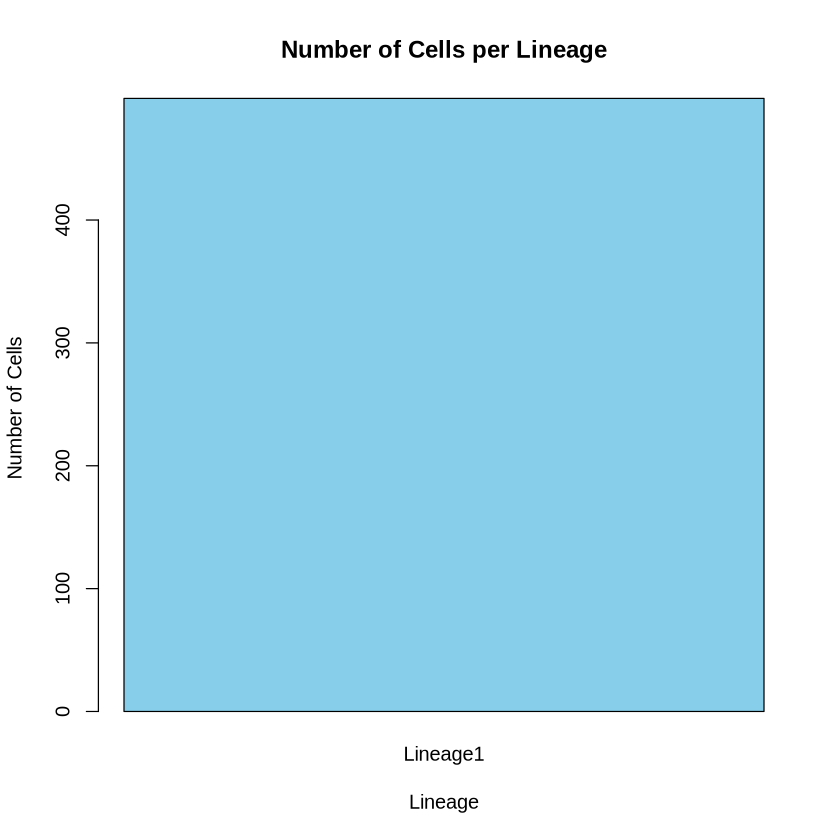

In [16]:
# 计算每个轨迹中的细胞数量（非NA值的数量）
cells_per_lineage <- apply(pseudotime, 2, function(x) sum(!is.na(x)))

print("Number of cells in each lineage:")
print(cells_per_lineage)

# 可视化细胞分布
barplot(cells_per_lineage, 
        main = "Number of Cells per Lineage",
        xlab = "Lineage", 
        ylab = "Number of Cells",
        col = "skyblue")

In [17]:
# 找到细胞数量最多的轨迹
max_cells_lineage <- names(which.max(cells_per_lineage))
print(paste("Lineage with most cells:", max_cells_lineage))

# 提取该轨迹的伪时间值
max_lineage_pseudotime <- pseudotime[, max_cells_lineage]

# 移除NA值（不属于该轨迹的细胞）
valid_cells <- !is.na(max_lineage_pseudotime)
max_lineage_pseudotime_clean <- max_lineage_pseudotime[valid_cells]


[1] "Lineage with most cells: Lineage1"


In [18]:
# 获取细胞名称（barcodes）
cell_barcodes <- rownames(pseudotime)[valid_cells]

# 创建包含细胞信息和伪时间的数据框
max_lineage_df <- data.frame(
  cell_barcode = cell_barcodes,
  pseudotime = max_lineage_pseudotime_clean,
  lineage = max_cells_lineage,
  stringsAsFactors = FALSE
)

# 按伪时间排序
max_lineage_df <- max_lineage_df[order(max_lineage_df$pseudotime), ]

# 查看前几行
print("Top cells in the lineage:")
print(max_lineage_df)

## 保存轨迹信息

In [21]:
# 定义输出文件名
output_filename <- paste0(data_path, "max_cells_lineage_", max_cells_lineage, "_pseudotime.csv")

# 保存为CSV
write.csv(max_lineage_df_unique, 
          file = output_filename, 
          row.names = FALSE, 
          quote = FALSE)

print(paste("Data saved to:", output_filename))

[1] "Data saved to: /home/liyang/BioWuYan/MethodTest/Data/All2/0process/max_cells_lineage_Lineage1_pseudotime.csv"
